# Regresor de Hiperplanos Locales con Coherencia Geométrica (LHR-C)

Este notebook amplía el concepto del **Regresor de Hiperplanos Locales (LHR)** para solucionar el problema del **aplanamiento de características locales** (como picos, valles o discontinuidades) cuando se muestrean subconjuntos de vecinos de forma puramente aleatoria.

## 1. Fundamento Teórico de la Coherencia Geométrica

Cuando el punto de consulta $x^*$ se encuentra cerca de un valor extremo (un pico o un valle de la función), sus $k$ vecinos más cercanos tienden a rodearlo y distribuirse a ambos lados del pico. Si seleccionamos subconjuntos de tamaño $n+1$ para construir un hiperplano y estos subconjuntos contienen puntos de ambos lados de la cima, el hiperplano resultante será plano, subestimando la altura del pico (efecto de aplanamiento o *smoothing* excesivo).

Para evitar esto, introducimos restricciones que guíen la selección de subconjuntos hacia puntos espacial y direccionalmente coherentes.

### Enfoque A: Coherencia Angular (Similitud de Coseno)
Definimos el vector relativo para cada vecino $i$ respecto a $x^*$:
$$v_i = x_i - x^*$$
Y su versión normalizada (vector unitario de dirección):
$$u_i = \frac{v_i}{\|v_i\|}$$

Para un subconjunto $S$ de tamaño $p$, definimos la **Coherencia Angular $C(S)$** como la similitud de coseno promedio de todos los pares dentro del subconjunto:
$$C(S) = \frac{2}{p(p-1)} \sum_{i < j \in S} u_i \cdot u_j$$

Si todos los puntos de $S$ están en la misma dirección relativa respecto a $x^*$ (del mismo "lado"), entonces $u_i \cdot u_j \approx 1 \implies C(S) \approx 1$. Si están en direcciones opuestas, $u_i \cdot u_j \approx -1 \implies C(S) \approx -1$.

#### Simplificación Matemática y Optimización $O(p)$
Calcular de forma iterativa todos los pares $i < j$ requiere un costo de $O(p^2)$ por subconjunto. Sin embargo, podemos simplificarlo usando la norma de la suma de vectores unitarios:
$$\left\| \sum_{i \in S} u_i \right\|^2 = \sum_{i \in S} \|u_i\|^2 + 2 \sum_{i < j \in S} u_i \cdot u_j$$
Como $\|u_i\|^2 = 1$ para vectores no nulos, la suma de normas al cuadrado es simplemente el número de elementos no nulos en el subconjunto ($p_{non\_zero}$). Por lo tanto:
$$\sum_{i < j \in S} u_i \cdot u_j = \frac{1}{2} \left( \left\| \sum_{i \in S} u_i \right\|^2 - \sum_{i \in S} \|u_i\|^2 \right)$$
Esto nos permite calcular $C(S)$ de manera vectorizada y ultra-rápida en $O(p)$ sumando las columnas de la matriz de vectores del subconjunto.

Muestreamos los subconjuntos usando la probabilidad:
$$P(S) \propto \exp(\lambda C(S)) \prod_{i \in S} \exp\left( -\frac{\|x_i - x^*\|^2}{h^2} \right)$$

Donde $\lambda$ controla la penalización angular y $h$ controla la penalización por distancia.

---

### Enfoque B: Vecindad Jerárquica ("Anchor KNN")
En lugar de muestrear candidatos en base a probabilidades complejas:
1. Seleccionamos un vecino "ancla" $x_a$ a partir de los vecinos de $x^*$ (con probabilidad inversamente proporcional a la distancia a $x^*$).
2. El subconjunto $S$ se define tomando $x_a$ y sus propios $n$ vecinos más cercanos de entrenamiento.
Esto garantiza de forma automática e implícita la coherencia espacial y direccional local sin cálculos trigonométricos.

---

### Enfoque C: Partición por Signos/Ortantes (PCA Local)
1. Ajustamos un PCA local en 1D (PC1) sobre los vecinos.
2. Proyectamos los puntos sobre PC1 y los etiquetamos como "izquierda" (proyección $<0$) o "derecha" (proyección $\ge 0$).
3. Muestreamos subconjuntos que pertenezcan únicamente al mismo lado de la proyección, previniendo mezclas de lados opuestos.

## 2. Configuración e Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools
import time
import math

# Estilo de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Implementación de la Clase `CoherentLocalHyperplaneRegressor`

In [2]:
class CoherentLocalHyperplaneRegressor:
    """
    Coherent Local Hyperplane Regressor (LHR-C)
    
    Algoritmo de regresión no paramétrico que construye hiperplanos locales
    a partir de subconjuntos geométricamente coherentes (angular y espacialmente)
    de los k-vecinos más cercanos de un punto de consulta.
    """
    def __init__(self, k=5, num_subsets=1000, cond_threshold=100.0, random_state=42):
        self.k = k
        self.num_subsets = num_subsets
        self.cond_threshold = cond_threshold
        self.random_state = random_state
        self.X_ = None
        self.y_ = None
        self.nn_ = None
        self.n_features_ = None
        
    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float)
        
        if self.X_.ndim != 2:
            raise ValueError(f"X debe ser una matriz 2D, pero tiene forma {self.X_.shape}")
        if self.y_.ndim != 1:
            raise ValueError(f"y debe ser un vector 1D, pero tiene forma {self.y_.shape}")
        if self.X_.shape[0] != self.y_.shape[0]:
            raise ValueError("X e y deben tener el mismo número de muestras.")
            
        n_samples, self.n_features_ = self.X_.shape
        min_k = self.n_features_ + 1
        
        if self.k < min_k:
            raise ValueError(f"k={self.k} es muy pequeño para n_features={self.n_features_}. "
                             f"k debe ser al menos n_features + 1 = {min_k}.")
        if n_samples < self.k:
            raise ValueError(f"Muestras de entrenamiento ({n_samples}) < k ({self.k})")
            
        self.nn_ = NearestNeighbors(n_neighbors=self.k)
        self.nn_.fit(self.X_)
        return self
        
    def predict_distribution(self, X_query, subset_size=None, method='angular', lambda_param=5.0, h_param=1.0):
        X_query = np.asarray(X_query, dtype=float)
        if X_query.ndim == 1:
            X_query = X_query.reshape(1, -1)
            
        if X_query.shape[1] != self.n_features_:
            raise ValueError(f"Dimensión de X_query ({X_query.shape[1]}) no coincide con "
                             f"la dimensión de entrenamiento ({self.n_features_})")
                             
        n_query = X_query.shape[0]
        n = self.n_features_
        size_subset = n + 1 if subset_size is None else subset_size
        
        if size_subset < n + 1:
            raise ValueError(f"subset_size ({size_subset}) debe ser al menos n_features + 1 = {n+1}")
            
        # Buscar los k vecinos más cercanos
        distances, indices = self.nn_.kneighbors(X_query)
        
        distributions = []
        neighbors_info = []
        
        rng = np.random.default_rng(self.random_state)
        
        for idx in range(n_query):
            x_q = X_query[idx]
            neighbor_idxs = indices[idx]
            neighbor_dists = distances[idx]
            
            X_neigh = self.X_[neighbor_idxs]
            y_neigh = self.y_[neighbor_idxs]
            
            # Calcular vectores relativos y normalizar para coherencia angular
            V = X_neigh - x_q  # (k, n)
            norms = np.linalg.norm(V, axis=1, keepdims=True)
            norms_safe = np.where(norms == 0.0, 1.0, norms)
            U = V / norms_safe  # (k, n)
            U[norms.flatten() == 0.0] = 0.0
            
            combos = []
            
            if method == 'angular':
                # 1. Determinar número de candidatos a evaluar por SIR
                total_combos_teorico = math.comb(self.k, size_subset)
                n_candidates = min(5000, total_combos_teorico)
                
                # Muestreo estocástico de combinaciones candidato únicas
                candidate_set = set()
                max_attempts = n_candidates * 10
                attempts = 0
                while len(candidate_set) < n_candidates and attempts < max_attempts:
                    c = tuple(sorted(rng.choice(self.k, size=size_subset, replace=False)))
                    candidate_set.add(c)
                    attempts += 1
                candidates = np.array(list(candidate_set))
                
                # 2. Calcular coherencia C(S) de manera eficiente en O(p)
                U_candidates = U[candidates]  # (n_candidates, size_subset, n)
                sum_u = np.sum(U_candidates, axis=1)  # (n_candidates, n)
                sum_u_norms_sq = np.sum(sum_u**2, axis=1)  # (n_candidates)
                
                u_norms_sq = np.sum(U**2, axis=1)  # (k)
                sum_individual_norms = np.sum(u_norms_sq[candidates], axis=1)  # (n_candidates)
                
                pairwise_sum = 0.5 * (sum_u_norms_sq - sum_individual_norms)
                C_S = 2.0 * pairwise_sum / (size_subset * (size_subset - 1))
                
                # 3. Calcular peso por distancia
                dist_sq = neighbor_dists**2  # (k)
                sum_dists_sq = np.sum(dist_sq[candidates], axis=1)  # (n_candidates)
                
                # 4. Pesos combinados y remuestreo
                log_weights = lambda_param * C_S - sum_dists_sq / (h_param**2)
                log_weights -= np.max(log_weights)  # Estabilidad numérica
                weights = np.exp(log_weights)
                weights /= np.sum(weights)
                
                selected_indices = rng.choice(len(candidates), size=self.num_subsets, p=weights, replace=True)
                combos = candidates[selected_indices]
                
            elif method == 'hierarchical':
                # Vecindad Jerárquica ("Anchor KNN")
                dist_sq = neighbor_dists**2
                log_probs = -dist_sq / (h_param**2)
                log_probs -= np.max(log_probs)
                probs = np.exp(log_probs)
                probs /= np.sum(probs)
                
                anchors = rng.choice(self.k, size=self.num_subsets, p=probs, replace=True)
                
                combos = []
                for a in anchors:
                    anchor_pt = X_neigh[a]
                    dists_to_anchor = np.linalg.norm(X_neigh - anchor_pt, axis=1)
                    closest_idxs = np.argsort(dists_to_anchor)[:size_subset]
                    combos.append(closest_idxs)
                combos = np.array(combos)
                
            elif method == 'orthant':
                # PCA Local en 1D para dividir el vecindario
                if self.k < 2:
                    all_combos = list(itertools.combinations(range(self.k), size_subset))
                    selected = rng.choice(len(all_combos), size=self.num_subsets, replace=True)
                    combos = np.array([all_combos[i] for i in selected])
                else:
                    try:
                        pca = PCA(n_components=1)
                        proj = pca.fit_transform(X_neigh).flatten()
                    except:
                        proj = X_neigh[:, 0]
                        
                    left_idxs = np.where(proj < 0.0)[0]
                    right_idxs = np.where(proj >= 0.0)[0]
                    
                    combos = []
                    for _ in range(self.num_subsets):
                        side = rng.choice(['left', 'right'])
                        if side == 'left' and len(left_idxs) >= size_subset:
                            c = rng.choice(left_idxs, size=size_subset, replace=False)
                        elif side == 'right' and len(right_idxs) >= size_subset:
                            c = rng.choice(right_idxs, size=size_subset, replace=False)
                        else:
                            if len(left_idxs) >= size_subset:
                                c = rng.choice(left_idxs, size=size_subset, replace=False)
                            elif len(right_idxs) >= size_subset:
                                c = rng.choice(right_idxs, size=size_subset, replace=False)
                            else:
                                c = rng.choice(self.k, size=size_subset, replace=False)
                        combos.append(c)
                    combos = np.array(combos)
            else:
                raise ValueError(f"Método de coherencia desconocido: {method}")
                
            # Resolver sistemas lineales locales vectorizados
            global_combos = neighbor_idxs[combos]
            X_sub = self.X_[global_combos]  # (M, size_subset, n)
            y_sub = self.y_[global_combos]  # (M, size_subset)
            
            ones = np.ones((self.num_subsets, size_subset, 1))
            A = np.concatenate([X_sub, ones], axis=2)  # (M, size_subset, n+1)
            
            A_T = A.transpose(0, 2, 1)
            A_normal = A_T @ A              # (M, n+1, n+1)
            Y_normal = A_T @ y_sub.reshape(self.num_subsets, size_subset, 1)  # (M, n+1, 1)
            
            effective_threshold = self.cond_threshold ** 2
            conds = np.linalg.cond(A_normal)
            valid_mask = conds < effective_threshold
            
            if not np.any(valid_mask):
                fallback_val = np.mean(self.y_[neighbor_idxs])
                distributions.append(np.array([fallback_val]))
                neighbors_info.append({
                    'neighbor_indices': neighbor_idxs,
                    'neighbor_distances': neighbor_dists,
                    'valid_subsets': 0,
                    'total_subsets': self.num_subsets,
                    'fallback_used': True
                })
                continue
                
            A_n_valid = A_normal[valid_mask]
            Y_n_valid = Y_normal[valid_mask]
            
            try:
                Z = np.linalg.solve(A_n_valid, Y_n_valid).squeeze(axis=2)  # (n_valid, n+1)
                x_q_aug = np.concatenate([x_q, [1.0]])
                preds = Z @ x_q_aug
                
                finite_mask = np.isfinite(preds)
                preds = preds[finite_mask]
                
                if len(preds) == 0:
                    preds = np.array([np.mean(self.y_[neighbor_idxs])])
                    fallback = True
                else:
                    fallback = False
            except np.linalg.LinAlgError:
                preds = np.array([np.mean(self.y_[neighbor_idxs])])
                fallback = True
                
            distributions.append(preds)
            neighbors_info.append({
                'neighbor_indices': neighbor_idxs,
                'neighbor_distances': neighbor_dists,
                'valid_subsets': len(preds) if not fallback else 0,
                'total_subsets': self.num_subsets,
                'fallback_used': fallback
            })
            
        return distributions, neighbors_info

    def predict(self, X_query, subset_size=None, method='angular', lambda_param=5.0, h_param=1.0, return_std=False, return_intervals=False, alpha=0.05, aggregation='mean'):
        distributions, _ = self.predict_distribution(
            X_query, subset_size=subset_size, method=method, lambda_param=lambda_param, h_param=h_param
        )
        
        y_pred = []
        y_std = []
        y_lower = []
        y_upper = []
        
        for dist in distributions:
            if aggregation == 'mean':
                y_pred.append(np.mean(dist))
            elif aggregation == 'median':
                y_pred.append(np.median(dist))
            else:
                raise ValueError(f"Método de agregación desconocido: {aggregation}")
                
            if return_std:
                y_std.append(np.std(dist) if len(dist) > 1 else 0.0)
                
            if return_intervals:
                if len(dist) > 1:
                    low_pct = 100 * (alpha / 2.0)
                    high_pct = 100 * (1.0 - alpha / 2.0)
                    y_lower.append(np.percentile(dist, low_pct))
                    y_upper.append(np.percentile(dist, high_pct))
                else:
                    y_lower.append(dist[0])
                    y_upper.append(dist[0])
                    
        y_pred = np.array(y_pred)
        results = [y_pred]
        
        if return_std:
            results.append(np.array(y_std))
        if return_intervals:
            results.append(np.array(y_lower))
            results.append(np.array(y_upper))
            
        if len(results) == 1:
            return results[0]
        else:
            return tuple(results)


## 4. Pruebas Unitarias Integradas

Validaremos el correcto funcionamiento de las 3 opciones de coherencia geométrica en casos base.

In [3]:
import unittest

class TestCoherentLocalHyperplaneRegressor(unittest.TestCase):
    def test_basic_linear_prediction(self):
        # Dataset lineal y = 3x - 1 perfecto
        X = np.linspace(-3, 3, 20).reshape(-1, 1)
        y = 3.0 * X.flatten() - 1.0
        
        reg = CoherentLocalHyperplaneRegressor(k=5, num_subsets=100)
        reg.fit(X, y)
        
        X_q = np.array([[1.0], [-2.0]])
        y_true = 3.0 * X_q.flatten() - 1.0
        
        # Evaluar los 3 métodos
        for method in ['angular', 'hierarchical', 'orthant']:
            dists, info = reg.predict_distribution(X_q, method=method)
            for i, dist in enumerate(dists):
                np.testing.assert_allclose(np.mean(dist), y_true[i], rtol=1e-9, atol=1e-9)
                self.assertFalse(info[i]['fallback_used'])
                
    def test_orthant_edge_case(self):
        # Probar comportamiento en 2D
        X = np.random.uniform(-2, 2, size=(30, 2))
        y = 2.0 * X[:, 0] + 1.5 * X[:, 1]
        
        reg = CoherentLocalHyperplaneRegressor(k=8, num_subsets=50)
        reg.fit(X, y)
        
        X_q = np.array([[0.5, -0.5]])
        y_true = 2.0 * X_q[:, 0] + 1.5 * X_q[:, 1]
        
        # Verificar que corra sin errores en 2D
        yp = reg.predict(X_q, method='orthant')
        np.testing.assert_allclose(yp, y_true, rtol=1e-9, atol=1e-9)

# Ejecutar tests
suite = unittest.TestLoader().loadTestsFromTestCase(TestCoherentLocalHyperplaneRegressor)
runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)

test_basic_linear_prediction (__main__.TestCoherentLocalHyperplaneRegressor) ... 

ok
test_orthant_edge_case (__main__.TestCoherentLocalHyperplaneRegressor) ... 

ok

----------------------------------------------------------------------
Ran 2 tests in 0.019s

OK


<unittest.runner.TextTestResult run=2 errors=0 failures=0>

## 5. Caso Sintético: El Pico de la Montaña (Función Absoluta en 1D)

Evaluaremos la hipótesis de la coherencia geométrica en una función no lineal con un pico pronunciado en $x=0$:
$$y = -|x| + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.05)$$

El punto crítico a predecir es justo en la cima: $x^* = 0.0$.
Aquí, los vecinos estarán a ambos lados. Queremos verificar si el LHR clásico "aplana" el pico y si los métodos coherentes logran preservarlo.

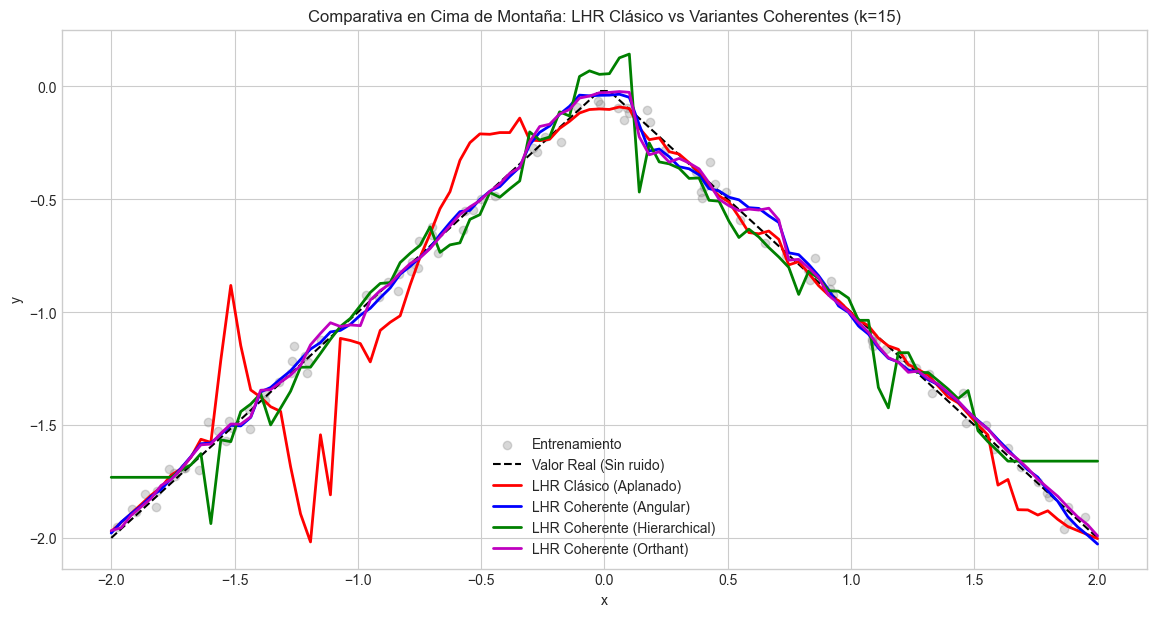

In [4]:
np.random.seed(42)
n_samples = 100
x_train = np.random.uniform(-2, 2, n_samples)
y_train = -np.abs(x_train) + np.random.normal(0, 0.05, len(x_train))

X_train_2d = x_train.reshape(-1, 1)
x_query = np.linspace(-2, 2, 100).reshape(-1, 1)

# Definir modelos
# 1. LHR Clásico (Muestreo completamente aleatorio de subconjuntos)
from sklearn.neighbors import NearestNeighbors
class ClassicLHR:
    def __init__(self, k=15, num_subsets=1000):
        self.k = k
        self.num_subsets = num_subsets
    def fit(self, X, y):
        self.X_ = np.asarray(X)
        self.y_ = np.asarray(y)
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(self.X_)
        return self
    def predict(self, X_query):
        distances, indices = self.nn_.kneighbors(X_query)
        preds = []
        rng = np.random.default_rng(42)
        all_combos = list(itertools.combinations(range(self.k), 2)) # 2 puntos para 1D
        combos = rng.choice(all_combos, size=self.num_subsets, replace=True)
        
        for idx in range(len(X_query)):
            x_q = X_query[idx]
            n_idx = indices[idx]
            y_pred_sub = []
            for c in combos:
                pts_idx = n_idx[c]
                x_pts = self.X_[pts_idx].flatten()
                y_pts = self.y_[pts_idx]
                # Recta: y = a*x + b
                if x_pts[1] == x_pts[0]:
                    continue
                slope = (y_pts[1] - y_pts[0]) / (x_pts[1] - x_pts[0])
                intercept = y_pts[0] - slope * x_pts[0]
                y_pred_sub.append(slope * x_q[0] + intercept)
            preds.append(np.mean(y_pred_sub) if len(y_pred_sub) > 0 else np.mean(self.y_[n_idx]))
        return np.array(preds)

classic = ClassicLHR(k=15, num_subsets=1000).fit(X_train_2d, y_train)
y_classic = classic.predict(x_query)

# 2. LHR Coherente (Angular)
lhr_c_ang = CoherentLocalHyperplaneRegressor(k=15, num_subsets=1000).fit(X_train_2d, y_train)
y_c_ang = lhr_c_ang.predict(x_query, method='angular', lambda_param=15.0, h_param=0.5)

# 3. LHR Coherente (Hierarchical)
y_c_hier = lhr_c_ang.predict(x_query, method='hierarchical', h_param=0.5)

# 4. LHR Coherente (Orthant)
y_c_orth = lhr_c_ang.predict(x_query, method='orthant')

# Graficar comparativa global
plt.figure(figsize=(14, 7))
plt.scatter(x_train, y_train, color='gray', alpha=0.3, label='Entrenamiento')
plt.plot(x_query, -np.abs(x_query), 'k--', lw=1.5, label='Valor Real (Sin ruido)')
plt.plot(x_query, y_classic, 'r-', lw=2, label='LHR Clásico (Aplanado)')
plt.plot(x_query, y_c_ang, 'b-', lw=2, label='LHR Coherente (Angular)')
plt.plot(x_query, y_c_hier, 'g-', lw=2, label='LHR Coherente (Hierarchical)')
plt.plot(x_query, y_c_orth, 'm-', lw=2, label='LHR Coherente (Orthant)')
plt.title('Comparativa en Cima de Montaña: LHR Clásico vs Variantes Coherentes (k=15)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower center')
plt.show()

### Análisis del Comportamiento en la Cima ($x^* = 0.0$)

Grafiquemos la distribución empírica de predicciones obtenida por el LHR Clásico y el LHR Coherente (Angular) en la cima exacta de la montaña ($x=0$).

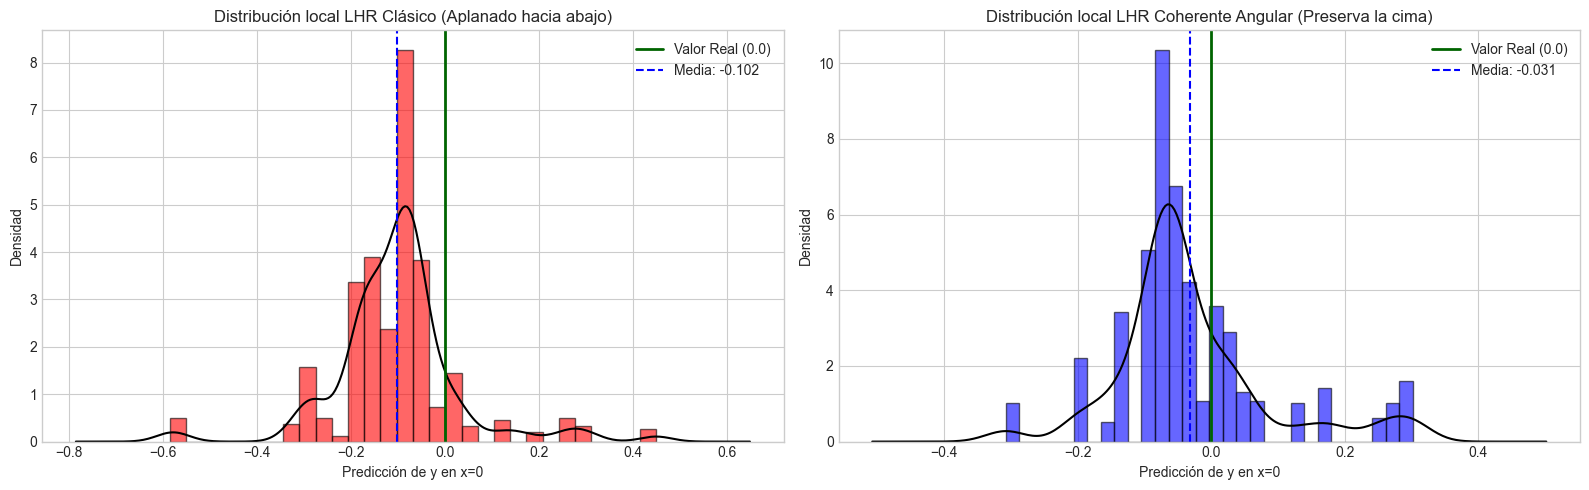

In [5]:
x_cima = np.array([[0.0]])

# Obtener distribuciones de predicciones
classic_neighbor_idxs = classic.nn_.kneighbors(x_cima)[1][0]
classic_combos = np.random.default_rng(42).choice(
    list(itertools.combinations(range(classic.k), 2)), size=classic.num_subsets, replace=True
)
classic_dist = []
for c in classic_combos:
    pts = classic_neighbor_idxs[c]
    x_pts = classic.X_[pts].flatten()
    y_pts = classic.y_[pts]
    if x_pts[0] != x_pts[1]:
        slope = (y_pts[1] - y_pts[0]) / (x_pts[1] - x_pts[0])
        intercept = y_pts[0] - slope * x_pts[0]
        classic_dist.append(intercept)  # Evaluado en x=0
classic_dist = np.array(classic_dist)

coherent_dists, _ = lhr_c_ang.predict_distribution(x_cima, method='angular', lambda_param=15.0, h_param=0.5)
coherent_dist = coherent_dists[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma LHR Clásico
axes[0].hist(classic_dist, bins=30, density=True, alpha=0.6, color='red', edgecolor='black')
if len(classic_dist) > 1 and np.var(classic_dist) > 1e-9:
    kde_cl = gaussian_kde(classic_dist)
    vals = np.linspace(min(classic_dist) - 0.2, max(classic_dist) + 0.2, 300)
    axes[0].plot(vals, kde_cl(vals), 'k-', lw=1.5)
axes[0].axvline(0.0, color='darkgreen', linestyle='-', lw=2, label='Valor Real (0.0)')
axes[0].axvline(np.mean(classic_dist), color='blue', linestyle='--', label=f'Media: {np.mean(classic_dist):.3f}')
axes[0].set_title('Distribución local LHR Clásico (Aplanado hacia abajo)')
axes[0].set_xlabel('Predicción de y en x=0')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Histograma LHR Coherente (Angular)
axes[1].hist(coherent_dist, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
if len(coherent_dist) > 1 and np.var(coherent_dist) > 1e-9:
    kde_co = gaussian_kde(coherent_dist)
    vals = np.linspace(min(coherent_dist) - 0.2, max(coherent_dist) + 0.2, 300)
    axes[1].plot(vals, kde_co(vals), 'k-', lw=1.5)
axes[1].axvline(0.0, color='darkgreen', linestyle='-', lw=2, label='Valor Real (0.0)')
axes[1].axvline(np.mean(coherent_dist), color='blue', linestyle='--', label=f'Media: {np.mean(coherent_dist):.3f}')
axes[1].set_title('Distribución local LHR Coherente Angular (Preserva la cima)')
axes[1].set_xlabel('Predicción de y en x=0')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Experimento en California Housing

Evaluaremos si la introducción de coherencia geométrica mejora la precisión de predicción en un dataset real de 8 dimensiones y alta densidad. Usaremos **$k=30$ vecinos** y evaluaremos a lo largo de **10 particiones aleatorias independientes**.

In [6]:
california = fetch_california_housing()
X_raw = california.data
y_raw = california.target

k_exp = 30
n_splits = 10
model_names = [
    'LHR Clásico (9 pts)',
    'LHR Coherente Angular (9 pts)',
    'LHR Coherente Hier. (9 pts)',
    'LHR Coherente Orthant (9 pts)',
    'KNN Estándar',
    'Regr. Lineal Local (LLR)'
]

stats = {name: {'mae': [], 'rmse': [], 'coverage': []} for name in model_names}

# Implementar LHR Clásico compatible para OLS/Exacto en n-D para comparación
class ClassicLHRND:
    def __init__(self, k=30, num_subsets=1000, cond_threshold=100.0):
        self.k = k
        self.num_subsets = num_subsets
        self.cond_threshold = cond_threshold
    def fit(self, X, y):
        self.X_ = np.asarray(X)
        self.y_ = np.asarray(y)
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(self.X_)
        self.n_features_ = self.X_.shape[1]
        return self
    def predict(self, X_query, subset_size=9, return_intervals=False):
        distances, indices = self.nn_.kneighbors(X_query)
        rng = np.random.default_rng(42)
        
        # Evitar itertools gigantesco, muestrear combinaciones
        combos_set = set()
        while len(combos_set) < self.num_subsets:
            c = tuple(sorted(rng.choice(self.k, size=subset_size, replace=False)))
            combos_set.add(c)
        combos = np.array(list(combos_set))
        
        preds_mean = []
        lows = []
        highs = []
        
        for idx in range(len(X_query)):
            x_q = X_query[idx]
            neighbor_idxs = indices[idx]
            global_combos = neighbor_idxs[combos]
            
            X_sub = self.X_[global_combos]
            y_sub = self.y_[global_combos]
            
            ones = np.ones((self.num_subsets, subset_size, 1))
            A = np.concatenate([X_sub, ones], axis=2)
            
            A_T = A.transpose(0, 2, 1)
            A_normal = A_T @ A
            Y_normal = A_T @ y_sub.reshape(self.num_subsets, subset_size, 1)
            
            conds = np.linalg.cond(A_normal)
            valid_mask = conds < (self.cond_threshold**2)
            
            if not np.any(valid_mask):
                pred_dist = np.array([np.mean(self.y_[neighbor_idxs])])
            else:
                A_n_valid = A_normal[valid_mask]
                Y_n_valid = Y_normal[valid_mask]
                try:
                    Z = np.linalg.solve(A_n_valid, Y_n_valid).squeeze(axis=2)
                    x_q_aug = np.concatenate([x_q, [1.0]])
                    pred_dist = Z @ x_q_aug
                except:
                    pred_dist = np.array([np.mean(self.y_[neighbor_idxs])])
            
            preds_mean.append(np.mean(pred_dist))
            if return_intervals:
                if len(pred_dist) > 1:
                    lows.append(np.percentile(pred_dist, 2.5))
                    highs.append(np.percentile(pred_dist, 97.5))
                else:
                    lows.append(pred_dist[0])
                    highs.append(pred_dist[0])
                    
        if return_intervals:
            return np.array(preds_mean), np.array(lows), np.array(highs)
        return np.array(preds_mean)

print(f"Iniciando evaluación de {n_splits} particiones independientes con k={k_exp}...")

for run in range(n_splits):
    X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
        X_raw, y_raw, train_size=1500, test_size=150, random_state=200 + run
    )
    
    scaler_sp = StandardScaler()
    X_train_sp_scaled = scaler_sp.fit_transform(X_train_sp)
    X_test_sp_scaled = scaler_sp.transform(X_test_sp)
    
    # 1. LHR Clásico
    lhr_classic = ClassicLHRND(k=k_exp, num_subsets=1000, cond_threshold=100.0)
    lhr_classic.fit(X_train_sp_scaled, y_train_sp)
    yp_c, yl_c, yh_c = lhr_classic.predict(X_test_sp_scaled, subset_size=9, return_intervals=True)
    stats['LHR Clásico (9 pts)']['mae'].append(np.mean(np.abs(y_test_sp - yp_c)))
    stats['LHR Clásico (9 pts)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp_c)**2)))
    stats['LHR Clásico (9 pts)']['coverage'].append(np.mean((y_test_sp >= yl_c) & (y_test_sp <= yh_c)))
    
    # Coherente
    lhr_coherent = CoherentLocalHyperplaneRegressor(k=k_exp, num_subsets=1000, cond_threshold=100.0)
    lhr_coherent.fit(X_train_sp_scaled, y_train_sp)
    
    # 2. LHR Coherente Angular
    yp_ang, yl_ang, yh_ang = lhr_coherent.predict(
        X_test_sp_scaled, subset_size=9, method='angular', lambda_param=10.0, h_param=1.0, return_intervals=True
    )
    stats['LHR Coherente Angular (9 pts)']['mae'].append(np.mean(np.abs(y_test_sp - yp_ang)))
    stats['LHR Coherente Angular (9 pts)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp_ang)**2)))
    stats['LHR Coherente Angular (9 pts)']['coverage'].append(np.mean((y_test_sp >= yl_ang) & (y_test_sp <= yh_ang)))
    
    # 3. LHR Coherente Hier.
    yp_hier, yl_hier, yh_hier = lhr_coherent.predict(
        X_test_sp_scaled, subset_size=9, method='hierarchical', h_param=1.0, return_intervals=True
    )
    stats['LHR Coherente Hier. (9 pts)']['mae'].append(np.mean(np.abs(y_test_sp - yp_hier)))
    stats['LHR Coherente Hier. (9 pts)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp_hier)**2)))
    stats['LHR Coherente Hier. (9 pts)']['coverage'].append(np.mean((y_test_sp >= yl_hier) & (y_test_sp <= yh_hier)))
    
    # 4. LHR Coherente Orthant
    yp_orth, yl_orth, yh_orth = lhr_coherent.predict(
        X_test_sp_scaled, subset_size=9, method='orthant', return_intervals=True
    )
    stats['LHR Coherente Orthant (9 pts)']['mae'].append(np.mean(np.abs(y_test_sp - yp_orth)))
    stats['LHR Coherente Orthant (9 pts)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp_orth)**2)))
    stats['LHR Coherente Orthant (9 pts)']['coverage'].append(np.mean((y_test_sp >= yl_orth) & (y_test_sp <= yh_orth)))
    
    # 5. KNN Estándar
    knn_sp = KNeighborsRegressor(n_neighbors=k_exp).fit(X_train_sp_scaled, y_train_sp)
    yp_knn = knn_sp.predict(X_test_sp_scaled)
    stats['KNN Estándar']['mae'].append(np.mean(np.abs(y_test_sp - yp_knn)))
    stats['KNN Estándar']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp_knn)**2)))
    
    # 6. LLR (Local Linear Regression)
    from sklearn.neighbors import NearestNeighbors
    nn_llr = NearestNeighbors(n_neighbors=k_exp).fit(X_train_sp_scaled)
    indices_llr = nn_llr.kneighbors(X_test_sp_scaled)[1]
    yp_llr = []
    for idx_q, n_idx in enumerate(indices_llr):
        lr = LinearRegression().fit(X_train_sp_scaled[n_idx], y_train_sp[n_idx])
        yp_llr.append(lr.predict(X_test_sp_scaled[idx_q].reshape(1, -1))[0])
    yp_llr = np.array(yp_llr)
    stats['Regr. Lineal Local (LLR)']['mae'].append(np.mean(np.abs(y_test_sp - yp_llr)))
    stats['Regr. Lineal Local (LLR)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp_llr)**2)))
    
    print(f"  Partición {run+1}/{n_splits} completada.")

print("\n====================================================================================================")
print(f"              ESTADÍSTICAS CONSOLIDADAS SOBRE {n_splits} PARTICIONES INDEPENDIENTES (k={k_exp})      ")
print("====================================================================================================")
for name in model_names:
    maes = stats[name]['mae']
    rmses = stats[name]['rmse']
    covs = stats[name]['coverage']
    cov_str = f"{np.mean(covs)*100:.2f}% +- {np.std(covs)*100:.2f}%" if len(covs) > 0 else "N/A"
    print(f"{name:32s} | MAE: {np.mean(maes):.4f} +- {np.std(maes):.4f} | RMSE: {np.mean(rmses):.4f} +- {np.std(rmses):.4f} | Cobertura: {cov_str}")
print("====================================================================================================")

Iniciando evaluación de 10 particiones independientes con k=30...


  Partición 1/10 completada.


  Partición 2/10 completada.


  Partición 3/10 completada.


  Partición 4/10 completada.


...

  Partición 6/10 completada.


  Partición 7/10 completada.


  Partición 8/10 completada.


  Partición 9/10 completada.


  Partición 10/10 completada.

              ESTADÍSTICAS CONSOLIDADAS SOBRE 10 PARTICIONES INDEPENDIENTES (k=30)      
LHR Clásico (9 pts)              | MAE: 0.5507 +- 0.1942 | RMSE: 1.5256 +- 2.4977 | Cobertura: 92.27% +- 10.28%
LHR Coherente Angular (9 pts)    | MAE: 0.4919 +- 0.0436 | RMSE: 0.6947 +- 0.0540 | Cobertura: 88.40% +- 9.51%
LHR Coherente Hier. (9 pts)      | MAE: 0.7939 +- 0.0735 | RMSE: 1.2386 +- 0.2005 | Cobertura: 44.07% +- 16.26%
LHR Coherente Orthant (9 pts)    | MAE: 0.6994 +- 0.1307 | RMSE: 1.2004 +- 0.7151 | Cobertura: 87.80% +- 13.67%
KNN Estándar                     | MAE: 0.5088 +- 0.0472 | RMSE: 0.6863 +- 0.0749 | Cobertura: N/A
Regr. Lineal Local (LLR)         | MAE: 0.4764 +- 0.0649 | RMSE: 0.9003 +- 0.7419 | Cobertura: N/A


## 7. Validación Estadística: Calibración de Incertidumbre y Cobertura de Cuantiles

Para verificar si la distribución de predicciones empírica generada por el LHR Coherente Angular tiene significado real, evaluaremos:
1. **Curva de Calibración de Incertidumbre**: Comprobar si los puntos donde el modelo estima una desviación estándar ($\sigma$ local) alta corresponden a un error absoluto real (MAE/RMSE) más alto.
2. **Calibración de Intervalos por Cuantiles**: Evaluar si los intervalos de confianza nominales (50%, 80%, 90% y 95%) corresponden con la cobertura real obtenida sobre el conjunto de prueba.

Coeficiente de correlación de Pearson entre Incertidumbre (std local) y MAE real: 0.4138

  Quintiles de Incertidumbre y Errores Reales Asociados
Quintil  | Uncert. Prom. (std)  | MAE Real   | RMSE Real 
-------------------------------------------------------
Quintil 1 |               0.3619 |     0.3151 |     0.5757
Quintil 2 |               0.7632 |     0.3542 |     0.4616
Quintil 3 |               1.0276 |     0.4193 |     0.5487
Quintil 4 |               1.3582 |     0.4714 |     0.6148
Quintil 5 |               2.3048 |     0.9987 |     1.3092


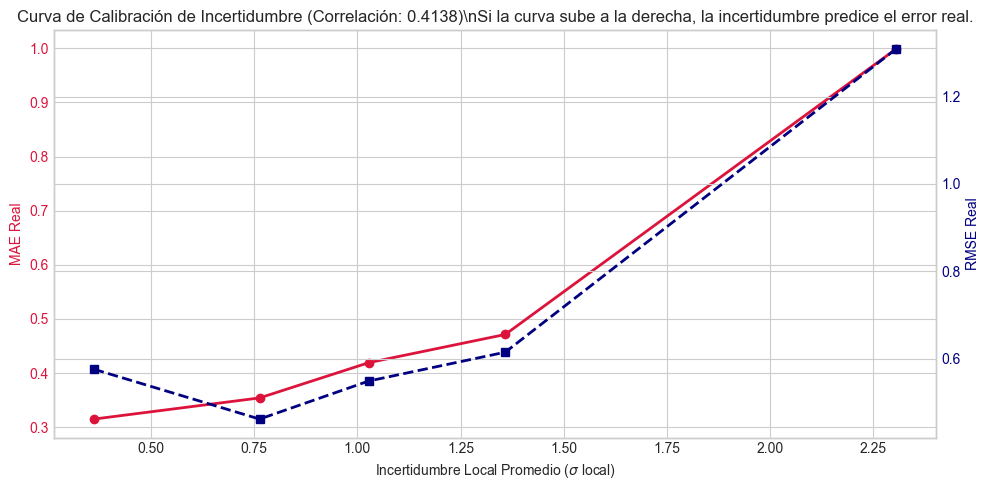

In [7]:
# 1. Curva de Calibración de Incertidumbre (σ vs. Error Real)
# Ajustar en una partición para la curva de calibración de incertidumbre
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, train_size=1500, test_size=500, random_state=42 # Más puntos de prueba para bins estables
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Usar LHR Coherente Angular
lhr_c = CoherentLocalHyperplaneRegressor(k=30, num_subsets=1000, cond_threshold=100.0, random_state=42)
lhr_c.fit(X_train_scaled, y_train)

# Obtener predicción y std local (incertidumbre)
y_pred, y_std = lhr_c.predict(
    X_test_scaled, subset_size=9, method='angular', lambda_param=10.0, h_param=1.0, return_std=True
)
abs_error = np.abs(y_test - y_pred)

# Coeficiente de correlación de Pearson
corr_val = np.corrcoef(y_std, abs_error)[0, 1]
print(f"Coeficiente de correlación de Pearson entre Incertidumbre (std local) y MAE real: {corr_val:.4f}")

# Dividir en quintiles de incertidumbre (y_std)
quantiles = np.percentile(y_std, [0, 20, 40, 60, 80, 100])
bin_indices = np.digitize(y_std, quantiles[:-1]) - 1
bin_indices = np.clip(bin_indices, 0, 4)

bin_mean_std = []
bin_mae = []
bin_rmse = []

print("\n=======================================================")
print("  Quintiles de Incertidumbre y Errores Reales Asociados")
print("=======================================================")
print(f"{'Quintil':8s} | {'Uncert. Prom. (std)':20s} | {'MAE Real':10s} | {'RMSE Real':10s}")
print("-------------------------------------------------------")
for b in range(5):
    mask = bin_indices == b
    mean_unc = np.mean(y_std[mask])
    mae = np.mean(abs_error[mask])
    rmse = np.sqrt(np.mean((y_test[mask] - y_pred[mask])**2))
    bin_mean_std.append(mean_unc)
    bin_mae.append(mae)
    bin_rmse.append(rmse)
    print(f"Quintil {b+1:d} | {mean_unc:20.4f} | {mae:10.4f} | {rmse:10.4f}")
print("=======================================================")

# Graficar curva de calibración de incertidumbre
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(bin_mean_std, bin_mae, 'o-', color='crimson', lw=2, label='MAE Real')
ax2.plot(bin_mean_std, bin_rmse, 's--', color='navy', lw=2, label='RMSE Real')

ax1.set_xlabel('Incertidumbre Local Promedio ($\\sigma$ local)')
ax1.set_ylabel('MAE Real', color='crimson')
ax2.set_ylabel('RMSE Real', color='navy')
ax1.tick_params(axis='y', labelcolor='crimson')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title(f'Curva de Calibración de Incertidumbre (Correlación: {corr_val:.4f})\\nSi la curva sube a la derecha, la incertidumbre predice el error real.')
plt.tight_layout()
plt.show()

Iniciando análisis de calibración de cuantiles en 10 splits independientes...


  Split 1/10 evaluado.


  Split 2/10 evaluado.


  Split 3/10 evaluado.


  Split 4/10 evaluado.


...

  Split 6/10 evaluado.


  Split 7/10 evaluado.


  Split 8/10 evaluado.


  Split 9/10 evaluado.


  Split 10/10 evaluado.

     CALIBRACIÓN DE COBERTURA DE INTERVALOS   
Cobertura Nominal    | Cobertura Real Promedio (± std)
----------------------------------------------
                50% |                      55.20% +- 17.10%
                80% |                      76.73% +- 22.84%
                90% |                      80.20% +- 22.64%
                95% |                      81.00% +- 22.89%


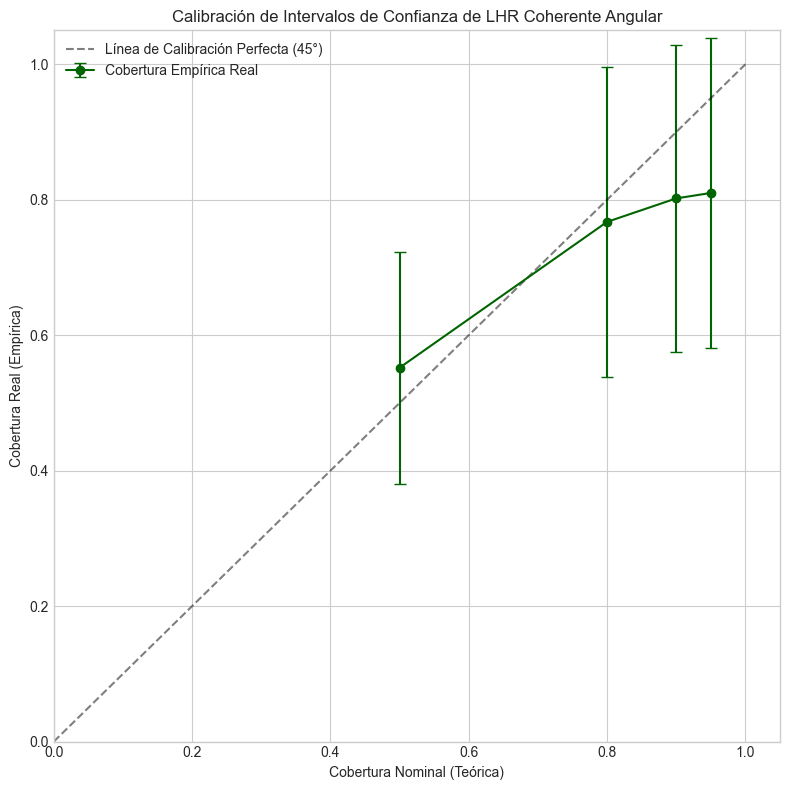

In [8]:
# 2. Experimento de Cobertura por Cuantiles en 10 Particiones
alphas = [0.50, 0.20, 0.10, 0.05]
nominal_coverages = [0.50, 0.80, 0.90, 0.95]
coverage_stats = {nc: [] for nc in nominal_coverages}

print("Iniciando análisis de calibración de cuantiles en 10 splits independientes...")
for run in range(n_splits):
    X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
        X_raw, y_raw, train_size=1500, test_size=150, random_state=300 + run
    )
    
    scaler_sp = StandardScaler()
    X_train_sp_scaled = scaler_sp.fit_transform(X_train_sp)
    X_test_sp_scaled = scaler_sp.transform(X_test_sp)
    
    lhr_coherent_sp = CoherentLocalHyperplaneRegressor(k=30, num_subsets=1000, cond_threshold=100.0, random_state=42)
    lhr_coherent_sp.fit(X_train_sp_scaled, y_train_sp)
    
    # Evaluar la cobertura real para cada cuantil
    for alpha, nc in zip(alphas, nominal_coverages):
        yp, yl, yh = lhr_coherent_sp.predict(
            X_test_sp_scaled, subset_size=9, method='angular', lambda_param=10.0, h_param=1.0, return_intervals=True, alpha=alpha
        )
        cov = np.mean((y_test_sp >= yl) & (y_test_sp <= yh))
        coverage_stats[nc].append(cov)
    print(f"  Split {run+1}/10 evaluado.")

print("\n==============================================")
print("     CALIBRACIÓN DE COBERTURA DE INTERVALOS   ")
print("==============================================")
col_title = "Cobertura Real Promedio (\u00b1 std)"
print(f"{'Cobertura Nominal':20s} | {col_title:30s}")
print("----------------------------------------------")
real_means = []
real_stds = []
for nc in nominal_coverages:
    mean_cov = np.mean(coverage_stats[nc])
    std_cov = np.std(coverage_stats[nc])
    real_means.append(mean_cov)
    real_stds.append(std_cov)
    print(f"{nc * 100:18.0f}% | {mean_cov * 100:26.2f}% +- {std_cov * 100:.2f}%")
print("==============================================")

# Graficar curva de calibración de cuantiles
plt.figure(figsize=(8, 8))
plt.errorbar(nominal_coverages, real_means, yerr=real_stds, fmt='o-', color='darkgreen', elinewidth=1.5, capsize=4, label='Cobertura Empírica Real')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Línea de Calibración Perfecta (45°)')
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.xlabel('Cobertura Nominal (Teórica)')
plt.ylabel('Cobertura Real (Empírica)')
plt.title('Calibración de Intervalos de Confianza de LHR Coherente Angular')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Comparación de Incertidumbre y Distribuciones con Modelos del Estado del Arte

Para poner en perspectiva el desempeño probabilístico de tu algoritmo, lo compararemos contra 6 métodos ampliamente consolidados para la cuantificación de incertidumbre:

1. **Quantile Regression Forest (QRF)**: Ensamblaje donde obtenemos la predicción de todos los árboles del bosque para estimar la distribución local y calcular cuantiles de forma empírica.
2. **Regresión por Procesos Gaussianos (GPR)**: Modelo Bayesiano no paramétrico que asume una distribución Gaussiana sobre las funciones, entregando directamente una media y desviación estándar analítica.
3. **Gradient Boosting con Pérdida por Cuantiles**: Ajuste de tres regresores Gradient Boosting de scikit-learn con pérdidas adaptadas a los cuantiles (mediana, cuantil inferior de 2.5% y superior de 97.5%).
4. **Predicción Conforme sobre LLR (Split Conformal LLR)**: Método libre de distribución que calibra el tamaño del intervalo de LLR midiendo los residuos absolutos sobre un conjunto de calibración.
5. **Bootstrap de Regresión Lineal Local (Bootstrap LLR)**: Remuestreo con reemplazo de los vecinos cercanos de cada punto de consulta para estimar una distribución de ajustes locales.
6. **Modelos Lineales Locales Bayesianos (Local Bayesian Ridge)**: Ajuste de un modelo de regresión lineal Bayesiano (con distribución a posteriori) únicamente sobre el vecindario local del punto de consulta.

Evaluaremos estos modelos en **3 particiones independientes** del dataset California Housing para obtener una comparativa de MAE, RMSE y Cobertura real del intervalo de confianza del 95%.

In [9]:
# Implementar los wrappers de modelos de benchmark
class QuantileRandomForest:
    def __init__(self, n_estimators=100, random_state=42):
        self.rf = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
    def fit(self, X, y):
        self.rf.fit(X, y)
        return self
    def predict(self, X_query, return_intervals=False, alpha=0.05):
        preds = np.array([tree.predict(X_query) for tree in self.rf.estimators_]).T  # (n_samples, n_estimators)
        y_pred = np.mean(preds, axis=1)
        if return_intervals:
            low_pct = 100.0 * (alpha / 2.0)
            high_pct = 100.0 * (1.0 - alpha / 2.0)
            y_lower = np.percentile(preds, low_pct, axis=1)
            y_upper = np.percentile(preds, high_pct, axis=1)
            return y_pred, y_lower, y_upper
        return y_pred

class GaussianProcessRegressorCustom:
    def __init__(self, random_state=42):
        kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5)
        self.gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, random_state=random_state)
    def fit(self, X, y):
        self.gp.fit(X, y)
        return self
    def predict(self, X_query, return_intervals=False, alpha=0.05):
        y_pred, y_std = self.gp.predict(X_query, return_std=True)
        if return_intervals:
            from scipy.stats import norm
            z = norm.ppf(1.0 - alpha / 2.0)
            y_lower = y_pred - z * y_std
            y_upper = y_pred + z * y_std
            return y_pred, y_lower, y_upper
        return y_pred

class QuantileGradientBoosting:
    def __init__(self, n_estimators=50, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
    def fit(self, X, y, alpha_val=0.05):
        self.model_median = GradientBoostingRegressor(loss='squared_error', n_estimators=self.n_estimators, random_state=self.random_state)
        self.model_lower = GradientBoostingRegressor(loss='quantile', alpha=alpha_val/2.0, n_estimators=self.n_estimators, random_state=self.random_state)
        self.model_upper = GradientBoostingRegressor(loss='quantile', alpha=1.0 - alpha_val/2.0, n_estimators=self.n_estimators, random_state=self.random_state)
        self.model_median.fit(X, y)
        self.model_lower.fit(X, y)
        self.model_upper.fit(X, y)
        return self
    def predict(self, X_query, return_intervals=False):
        y_pred = self.model_median.predict(X_query)
        if return_intervals:
            y_lower = self.model_lower.predict(X_query)
            y_upper = self.model_upper.predict(X_query)
            return y_pred, y_lower, y_upper
        return y_pred

class LocalLinearRegressorCustom:
    def __init__(self, k=30):
        self.k = k
    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float)
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(self.X_)
        return self
    def predict(self, X_query):
        distances, indices = self.nn_.kneighbors(X_query)
        preds = []
        for idx in range(len(X_query)):
            lr = LinearRegression().fit(self.X_[indices[idx]], self.y_[indices[idx]])
            preds.append(lr.predict(X_query[idx].reshape(1, -1))[0])
        return np.array(preds)

class ConformalLLR:
    def __init__(self, k=30):
        self.k = k
    def fit(self, X, y, alpha=0.05):
        # Dividir entrenamiento base y calibración
        X_tr, X_cal, y_tr, y_cal = train_test_split(X, y, test_size=0.3, random_state=42)
        self.llr = LocalLinearRegressorCustom(k=self.k).fit(X_tr, y_tr)
        y_pred_cal = self.llr.predict(X_cal)
        residuals = np.abs(y_cal - y_pred_cal)
        n_cal = len(X_cal)
        q_level = (1.0 - alpha) * (1.0 + 1.0 / n_cal)
        q_level = np.clip(q_level, 0.0, 1.0)
        self.q_width = np.percentile(residuals, q_level * 100.0)
        return self
    def predict(self, X_query, return_intervals=False):
        y_pred = self.llr.predict(X_query)
        if return_intervals:
            y_lower = y_pred - self.q_width
            y_upper = y_pred + self.q_width
            return y_pred, y_lower, y_upper
        return y_pred

class BootstrapLLR:
    def __init__(self, k=30, B=50, random_state=42):
        self.k = k
        self.B = B
        self.random_state = random_state
    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float)
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(self.X_)
        return self
    def predict(self, X_query, return_intervals=False, alpha=0.05):
        distances, indices = self.nn_.kneighbors(X_query)
        rng = np.random.default_rng(self.random_state)
        y_pred = []
        y_lower = []
        y_upper = []
        low_pct = 100.0 * (alpha / 2.0)
        high_pct = 100.0 * (1.0 - alpha / 2.0)
        
        for idx in range(len(X_query)):
            x_q = X_query[idx].reshape(1, -1)
            n_idx = indices[idx]
            X_neigh = self.X_[n_idx]
            y_neigh = self.y_[n_idx]
            
            preds = []
            for _ in range(self.B):
                b_idx = rng.choice(self.k, size=self.k, replace=True)
                try:
                    lr = LinearRegression().fit(X_neigh[b_idx], y_neigh[b_idx])
                    preds.append(lr.predict(x_q)[0])
                except:
                    preds.append(np.mean(y_neigh[b_idx]))
            
            y_pred.append(np.mean(preds))
            if return_intervals:
                y_lower.append(np.percentile(preds, low_pct))
                y_upper.append(np.percentile(preds, high_pct))
                
        y_pred = np.array(y_pred)
        if return_intervals:
            return y_pred, np.array(y_lower), np.array(y_upper)
        return y_pred

class BayesianLocalLinearRegressor:
    def __init__(self, k=30):
        self.k = k
    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float)
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(self.X_)
        return self
    def predict(self, X_query, return_intervals=False, alpha=0.05):
        distances, indices = self.nn_.kneighbors(X_query)
        y_pred = []
        y_std = []
        for idx in range(len(X_query)):
            x_q = X_query[idx].reshape(1, -1)
            n_idx = indices[idx]
            br = BayesianRidge()
            br.fit(self.X_[n_idx], self.y_[n_idx])
            mean, std = br.predict(x_q, return_std=True)
            y_pred.append(mean[0])
            y_std.append(std[0])
            
        y_pred = np.array(y_pred)
        y_std = np.array(y_std)
        if return_intervals:
            from scipy.stats import norm
            z = norm.ppf(1.0 - alpha / 2.0)
            y_lower = y_pred - z * y_std
            y_upper = y_pred + z * y_std
            return y_pred, y_lower, y_upper
        return y_pred
print("Modelos de benchmark definidos exitosamente.")

Modelos de benchmark definidos exitosamente.


In [10]:
# Evaluar todos los modelos en 3 splits independientes de California Housing
n_splits_bench = 3
k_bench = 30

bench_models = [
    'LHR Coherente Angular (9 pts)',
    'Quantile Regression Forest (QRF)',
    'Gaussian Process Regression (GPR)',
    'Gradient Boosting Quantile',
    'Conformal LLR',
    'Bootstrap LLR',
    'Local Bayesian Ridge',
    'KNN Estándar',
    'Regr. Lineal Local (LLR)'
]

bench_stats = {name: {'mae': [], 'rmse': [], 'coverage': []} for name in bench_models}

print(f"Iniciando benchmark en {n_splits_bench} splits independientes con k={k_bench} vecinos...")

for run in range(n_splits_bench):
    t_start = time.time()
    X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
        X_raw, y_raw, train_size=1500, test_size=150, random_state=400 + run
    )
    
    scaler_sp = StandardScaler()
    X_train_sp_scaled = scaler_sp.fit_transform(X_train_sp)
    X_test_sp_scaled = scaler_sp.transform(X_test_sp)
    
    # 1. LHR Coherente Angular
    lhr_coherent = CoherentLocalHyperplaneRegressor(k=k_bench, num_subsets=1000, cond_threshold=100.0, random_state=42)
    lhr_coherent.fit(X_train_sp_scaled, y_train_sp)
    yp, yl, yh = lhr_coherent.predict(X_test_sp_scaled, subset_size=9, method='angular', lambda_param=10.0, h_param=1.0, return_intervals=True, alpha=0.05)
    bench_stats['LHR Coherente Angular (9 pts)']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['LHR Coherente Angular (9 pts)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['LHR Coherente Angular (9 pts)']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 2. QRF
    qrf = QuantileRandomForest(n_estimators=100, random_state=42).fit(X_train_sp_scaled, y_train_sp)
    yp, yl, yh = qrf.predict(X_test_sp_scaled, return_intervals=True, alpha=0.05)
    bench_stats['Quantile Regression Forest (QRF)']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Quantile Regression Forest (QRF)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['Quantile Regression Forest (QRF)']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 3. GPR
    gpr = GaussianProcessRegressorCustom(random_state=42).fit(X_train_sp_scaled, y_train_sp)
    yp, yl, yh = gpr.predict(X_test_sp_scaled, return_intervals=True, alpha=0.05)
    bench_stats['Gaussian Process Regression (GPR)']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Gaussian Process Regression (GPR)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['Gaussian Process Regression (GPR)']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 4. GBDT Quantile
    gbdt = QuantileGradientBoosting(n_estimators=50, random_state=42).fit(X_train_sp_scaled, y_train_sp, alpha_val=0.05)
    yp, yl, yh = gbdt.predict(X_test_sp_scaled, return_intervals=True)
    bench_stats['Gradient Boosting Quantile']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Gradient Boosting Quantile']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['Gradient Boosting Quantile']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 5. Conformal LLR
    c_llr = ConformalLLR(k=k_bench).fit(X_train_sp_scaled, y_train_sp, alpha=0.05)
    yp, yl, yh = c_llr.predict(X_test_sp_scaled, return_intervals=True)
    bench_stats['Conformal LLR']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Conformal LLR']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['Conformal LLR']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 6. Bootstrap LLR
    boot_llr = BootstrapLLR(k=k_bench, B=50, random_state=42).fit(X_train_sp_scaled, y_train_sp)
    yp, yl, yh = boot_llr.predict(X_test_sp_scaled, return_intervals=True, alpha=0.05)
    bench_stats['Bootstrap LLR']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Bootstrap LLR']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['Bootstrap LLR']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 7. Local Bayesian Ridge
    bay_local = BayesianLocalLinearRegressor(k=k_bench).fit(X_train_sp_scaled, y_train_sp)
    yp, yl, yh = bay_local.predict(X_test_sp_scaled, return_intervals=True, alpha=0.05)
    bench_stats['Local Bayesian Ridge']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Local Bayesian Ridge']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    bench_stats['Local Bayesian Ridge']['coverage'].append(np.mean((y_test_sp >= yl) & (y_test_sp <= yh)))
    
    # 8. KNN
    knn = KNeighborsRegressor(n_neighbors=k_bench).fit(X_train_sp_scaled, y_train_sp)
    yp = knn.predict(X_test_sp_scaled)
    bench_stats['KNN Estándar']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['KNN Estándar']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    
    # 9. LLR
    llr = LocalLinearRegressorCustom(k=k_bench).fit(X_train_sp_scaled, y_train_sp)
    yp = llr.predict(X_test_sp_scaled)
    bench_stats['Regr. Lineal Local (LLR)']['mae'].append(np.mean(np.abs(y_test_sp - yp)))
    bench_stats['Regr. Lineal Local (LLR)']['rmse'].append(np.sqrt(np.mean((y_test_sp - yp)**2)))
    
    print(f"  Split {run+1}/{n_splits_bench} completado en {time.time() - t_start:.2f} s.")

print("\n====================================================================================================")
print(f"              BENCHMARK DE INCERTIDUMBRE Y PRECISIÓN (Consolidado sobre {n_splits_bench} splits)    ")
print("====================================================================================================")
for name in bench_models:
    maes = bench_stats[name]['mae']
    rmses = bench_stats[name]['rmse']
    covs = bench_stats[name]['coverage']
    cov_str = f"{np.mean(covs)*100:.2f}% +- {np.std(covs)*100:.2f}%" if len(covs) > 0 else "N/A"
    print(f"{name:32s} | MAE: {np.mean(maes):.4f} +- {np.std(maes):.4f} | RMSE: {np.mean(rmses):.4f} +- {np.std(rmses):.4f} | Cobertura (95%): {cov_str}")
print("====================================================================================================")

Iniciando benchmark en 3 splits independientes con k=30 vecinos...


  Split 1/3 completado en 11.31 s.


  Split 2/3 completado en 10.95 s.


  Split 3/3 completado en 11.41 s.

              BENCHMARK DE INCERTIDUMBRE Y PRECISIÓN (Consolidado sobre 3 splits)    
LHR Coherente Angular (9 pts)    | MAE: 0.5288 +- 0.0410 | RMSE: 0.7323 +- 0.0629 | Cobertura (95%): 79.56% +- 12.99%
Quantile Regression Forest (QRF) | MAE: 0.4438 +- 0.0201 | RMSE: 0.6475 +- 0.0379 | Cobertura (95%): 93.11% +- 1.91%
Gaussian Process Regression (GPR) | MAE: 0.4477 +- 0.0390 | RMSE: 0.6399 +- 0.0532 | Cobertura (95%): 80.22% +- 3.62%
Gradient Boosting Quantile       | MAE: 0.4428 +- 0.0042 | RMSE: 0.6291 +- 0.0229 | Cobertura (95%): 91.78% +- 1.66%
Conformal LLR                    | MAE: 0.5274 +- 0.0379 | RMSE: 0.7297 +- 0.0686 | Cobertura (95%): 93.33% +- 0.54%
Bootstrap LLR                    | MAE: 0.4861 +- 0.0528 | RMSE: 0.6851 +- 0.0953 | Cobertura (95%): 70.44% +- 0.83%
Local Bayesian Ridge             | MAE: 0.4789 +- 0.0407 | RMSE: 0.6563 +- 0.0635 | Cobertura (95%): 97.11% +- 1.13%
KNN Estándar                     | MAE: 0.5573 +- 0.0201 